# Analysis of the Gun Violence Dataset

# Predictive Modeling of Incident Severity

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----

In this notebook, we build models to predict the severity of gun violence incidents.

We frame the problem in 4 different ways:
1. **Total Casualties (Regression):** Predicting `n_killed + n_injured`. 
2. **Severity Tiers (Classification):** Categorizing incidents into ordinal tiers (`No Casualties`, `Minor`, `Mass Casualty`).
4. **Casualties vs No Casualties (Classification):** Binary prediciton of `n_killed + n_injured > 0`.
4. **Lethality Ratio (Regression):** Predicting `n_killed / (n_killed + n_injured)` for incidents with casualties.

We utilize **Random Forests** which handle missing values natively in scikit-learn. This is important for our dataset as missingness is a significant problem (described in [01_problem_and_data_understanding.ipynb](01_problem_and_data_understanding.ipynb)).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    KFold,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

np.random.seed(42)

## 1. Load Data & Create Targets

In [2]:
df = pd.read_parquet("../data/incidents.parquet")

# Date features
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Total causalties
df["target_total_casualties"] = df["n_killed"] + df["n_injured"]

# Lethality ratio (only for incidents with at least 1 casualty)
df["target_lethality_ratio"] = np.where(
    df["target_total_casualties"] > 0,
    df["n_killed"] / df["target_total_casualties"],
    np.nan,
)


def get_severity_tier(casualties: int) -> int:
    if casualties == 0:
        return 0  # 0: No Casualties
    elif casualties < 4:
        return 1  # 1: Minor (1-3 casualties)
    else:
        return 2  # 2: Mass Casualty (>= 4 casualties, standard GVA definition)


df["target_severity_tier"] = df["target_total_casualties"].apply(get_severity_tier)
df["target_severity_tier"].value_counts(normalize=True)

target_severity_tier
1    0.585321
0    0.405909
2    0.008770
Name: proportion, dtype: float64

## 2. Feature Selection & Preparation

For modeling incident severity, we avoid using features that are a direct *result* of the severity (data leakage). 
We also want to avoid discarding data. Since we have missing values in features like `n_guns_involved`, we use Random Forest estimators, which can natively handle `NaN`s without explicit imputation.

Selected Features:
- `state`: categorical
- `month`, `day_of_week`, `is_weekend`: temporal context
- `n_guns_involved`: available capacity for violence
- `latitude`, `longitude`: geographical context 

In [3]:
features = [
    "state",
    "month",
    "day_of_week",
    "is_weekend",
    "n_guns_involved",
    "latitude",
    "longitude",
]

X_raw = df[features].copy()
X = pd.get_dummies(X_raw, columns=["state", "month", "day_of_week"], drop_first=True)

## 3. Modeling

### 3.1 Total Casualties (Regression)

In [4]:
param_distributions = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [10, 20, 50],
    "max_features": ["sqrt", "log2", 1],  # 1 is equivalent to using all features
}

In [5]:
y_tot_cas = df["target_total_casualties"]
X_train_tc, X_test_tc, y_train_tc, y_test_tc = train_test_split(
    X, y_tot_cas, test_size=0.2, random_state=42
)

search_tc = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
)

In [6]:
search_tc.fit(X_train_tc, y_train_tc)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

Best Parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 0.5434
Test MAE: 0.5414
Test RMSE: 0.7628


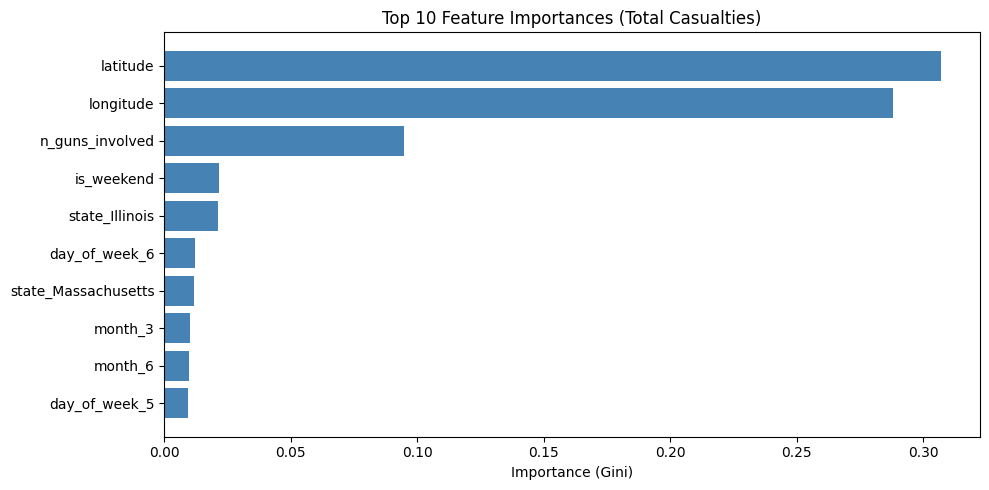

In [7]:
print("Best Parameters:", search_tc.best_params_)
print(f"Best CV MAE: {-search_tc.best_score_:.4f}")

best_rf_tc = search_tc.best_estimator_
y_pred_tc = best_rf_tc.predict(X_test_tc)
print(f"Test MAE: {mean_absolute_error(y_test_tc, y_pred_tc):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_tc, y_pred_tc)):.4f}")

# Plot feature importances
importances_tc = best_rf_tc.feature_importances_
top_idx_tc = np.argsort(importances_tc)[-10:]
plt.figure(figsize=(10, 5))
plt.barh(X.columns[top_idx_tc], importances_tc[top_idx_tc], color="steelblue")
plt.title("Top 10 Feature Importances (Total Casualties)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

### 3.2 Severity Tiers (Classification)

We classify into `No Casualties` (0), `Minor` (1), and `Mass Casualty` (2).

In [8]:
y_tier = df["target_severity_tier"]
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X, y_tier, test_size=0.2, stratify=y_tier, random_state=42
)

search_st = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
)

In [9]:
search_st.fit(X_train_st, y_train_st)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [10]:
print("Best Parameters:", search_st.best_params_)
print(f"Best CV Macro F1: {search_st.best_score_:.4f}")

best_rf_st = search_st.best_estimator_
y_pred_st = best_rf_st.predict(X_test_st)
print("\nClassification Report (Test Set):")
print(
    classification_report(
        y_test_st,
        y_pred_st,
        target_names=["No Casualties (0)", "Minor (1)", "Mass Casualty (2)"],
    )
)

Best Parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}
Best CV Macro F1: 0.4246

Classification Report (Test Set):
                   precision    recall  f1-score   support

No Casualties (0)       0.66      0.45      0.54     19458
        Minor (1)       0.68      0.84      0.75     28058
Mass Casualty (2)       0.00      0.00      0.00       420

         accuracy                           0.68     47936
        macro avg       0.45      0.43      0.43     47936
     weighted avg       0.67      0.68      0.66     47936



c:\Users\kacpe\Desktop\gun-violence-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kacpe\Desktop\gun-violence-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kacpe\Desktop\gun-violence-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

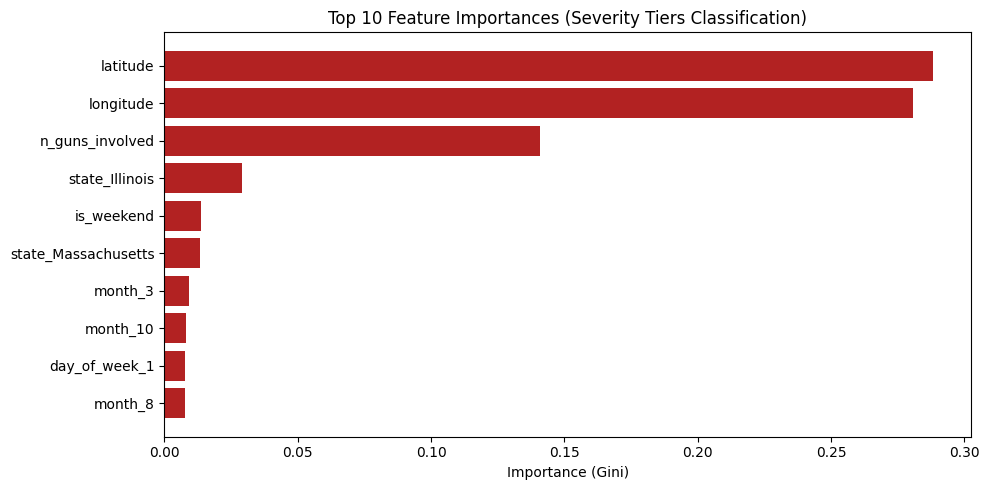

In [11]:
importances_st = best_rf_st.feature_importances_
top_idx_st = np.argsort(importances_st)[-10:]
plt.figure(figsize=(10, 5))
plt.barh(X.columns[top_idx_st], importances_st[top_idx_st], color="firebrick")
plt.title("Top 10 Feature Importances (Severity Tiers Classification)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

### 3.3 Casualties vs. No Casualties (Binary Classification)

Instead of isolating mass shootings, we can frame this as predicting whether an incident will have **any casualties at all** (Killed + Injured > 0) versus **no casualties** (property damage, shots fired, but no one hit). This is a more balanced binary problem.

In [12]:
# Binary target: 1 if any casualties, 0 otherwise
df["target_has_casualties"] = (df["target_total_casualties"] > 0).astype(int)
df["target_has_casualties"].value_counts(normalize=True)

target_has_casualties
1    0.594091
0    0.405909
Name: proportion, dtype: float64

In [13]:
y_bin = df["target_has_casualties"]
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

search_bin = RandomizedSearchCV(
    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
)

In [14]:
search_bin.fit(X_train_bin, y_train_bin)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [15]:
print("Best Parameters:", search_bin.best_params_)
print(f"Best CV Macro F1: {search_bin.best_score_:.4f}")

best_rf_bin = search_bin.best_estimator_
y_pred_bin = best_rf_bin.predict(X_test_bin)
print("\nClassification Report - Casualties vs. No Casualties:")
print(
    classification_report(
        y_test_bin, y_pred_bin, target_names=["No Casualties (0)", "Has Casualties (1)"]
    )
)

Best Parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}
Best CV Macro F1: 0.6382

Classification Report - Casualties vs. No Casualties:
                    precision    recall  f1-score   support

 No Casualties (0)       0.66      0.44      0.53     19458
Has Casualties (1)       0.69      0.85      0.76     28478

          accuracy                           0.68     47936
         macro avg       0.68      0.64      0.64     47936
      weighted avg       0.68      0.68      0.67     47936



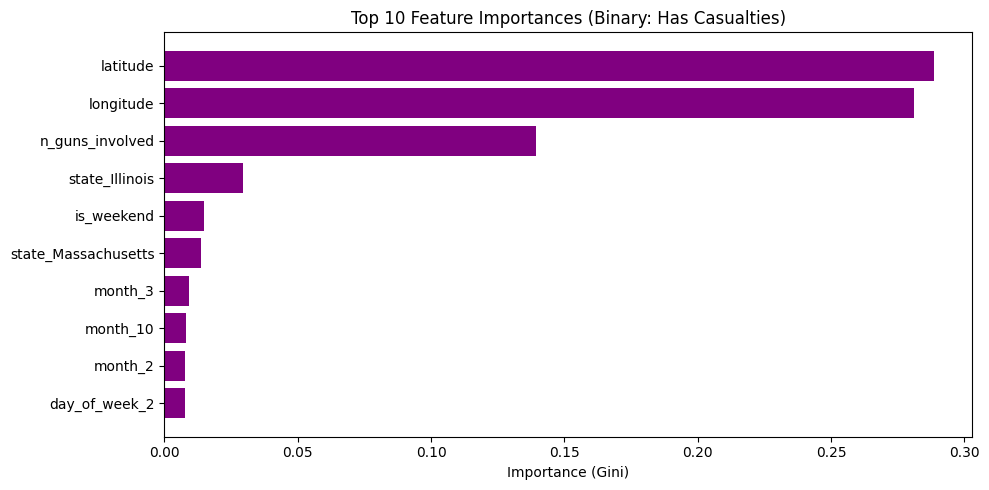

In [16]:
importances_bin = best_rf_bin.feature_importances_
top_idx_bin = np.argsort(importances_bin)[-10:]

plt.figure(figsize=(10, 5))
plt.barh(X.columns[top_idx_bin], importances_bin[top_idx_bin], color="purple")
plt.title("Top 10 Feature Importances (Binary: Has Casualties)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

### 3.4 Lethality Ratio (Regression)

We filter for incidents where `total_casualties > 0`. This checks: *given that someone was shot, how lethal was the incident?*

In [17]:
mask_casualties = df["target_total_casualties"] > 0
X_lethal = X[mask_casualties].copy()
X_lethal.shape

(142390, 71)

In [18]:
y_lethal = df.loc[mask_casualties, "target_lethality_ratio"]
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lethal, y_lethal, test_size=0.2, random_state=42
)

search_lr = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
)

In [19]:
search_lr.fit(X_train_lr, y_train_lr)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [10, 20, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

Best Parameters: {'n_estimators': 150, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 0.4116
Test MAE (Lethality Ratio): 0.4108
Test RMSE (Lethality Ratio): 0.4483


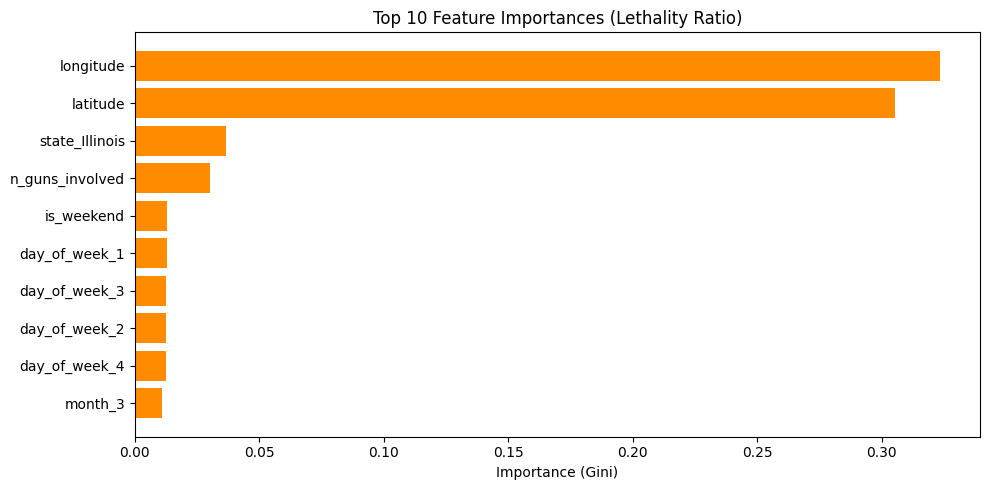

In [20]:
print("Best Parameters:", search_lr.best_params_)
print(f"Best CV MAE: {-search_lr.best_score_:.4f}")

best_rf_lr = search_lr.best_estimator_
y_pred_lr = best_rf_lr.predict(X_test_lr)

print(f"Test MAE (Lethality Ratio): {mean_absolute_error(y_test_lr, y_pred_lr):.4f}")
print(
    f"Test RMSE (Lethality Ratio): {np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)):.4f}"
)

importances_lr = best_rf_lr.feature_importances_
top_idx_lr = np.argsort(importances_lr)[-10:]
plt.figure(figsize=(10, 5))
plt.barh(X_lethal.columns[top_idx_lr], importances_lr[top_idx_lr], color="darkorange")
plt.title("Top 10 Feature Importances (Lethality Ratio)")
plt.xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()